In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from typing import List

In [37]:
ds = xr.open_dataset('Boundary_Layer_REA_Data.nc')

In [38]:
ds2 = xr.open_dataset('Boundary_Layer_REA_Data.nc')

In [39]:
ds2['valid_time'] = ds2['valid_time'] - pd.Timedelta(hours=3)

In [5]:
ds

<xarray.Dataset> Size: 29MB
Dimensions:     (valid_time: 1464, latitude: 41, longitude: 121)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 12kB 2012-09-01 ... 2012-10-31T23...
  * latitude    (latitude) float64 328B -5.0 -5.25 -5.5 ... -14.5 -14.75 -15.0
  * longitude   (longitude) float64 968B -70.0 -69.75 -69.5 ... -40.25 -40.0
    expver      (valid_time) <U4 23kB ...
Data variables:
    blh         (valid_time, latitude, longitude) float32 29MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-03T09:41 GRIB to CDM+CF via cfgrib-0.9.1...

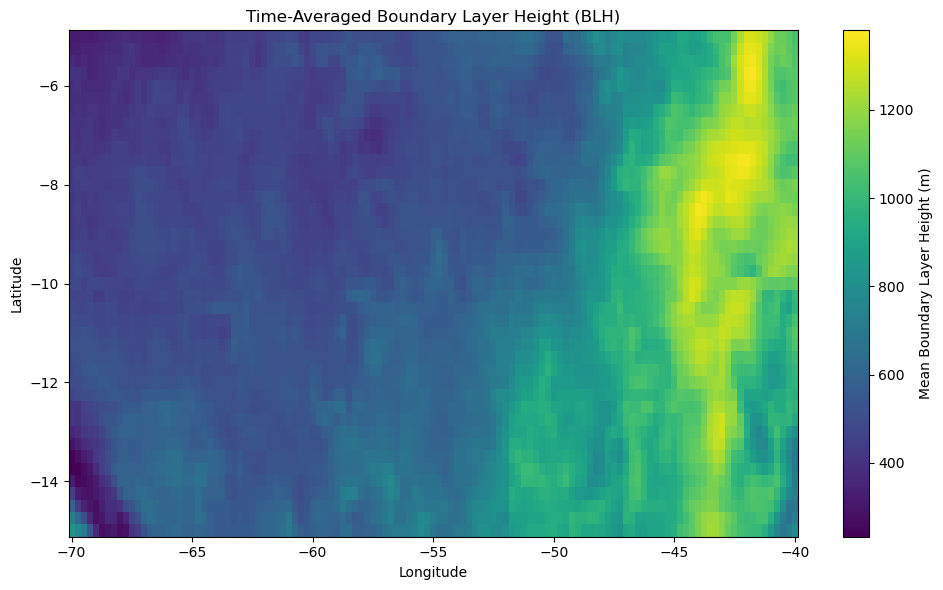

In [6]:
# Assume your dataset is already loaded as `ds`
# Time-average over the 'valid_time' dimension
blh_mean = ds['blh'].mean(dim='valid_time')

# Plot using matplotlib and pcolormesh
plt.figure(figsize=(10, 6))
plt.pcolormesh(ds['longitude'], ds['latitude'], blh_mean,
               shading='auto', cmap='viridis')
plt.colorbar(label='Mean Boundary Layer Height (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Time-Averaged Boundary Layer Height (BLH)')
plt.tight_layout()
plt.show()


In [7]:
ex_point = (ds2["latitude"] == -8) & (ds2['longitude'] == -56)
filtered_ds = ds2.where(ex_point, drop=True)

In [8]:
filtered_ds['valid_time'][1]

<xarray.DataArray 'valid_time' ()> Size: 8B
array('2012-08-31T22:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2012-08-31T22:00:00
    expver      <U4 16B ...

(15584.291666666666, 15584.875)

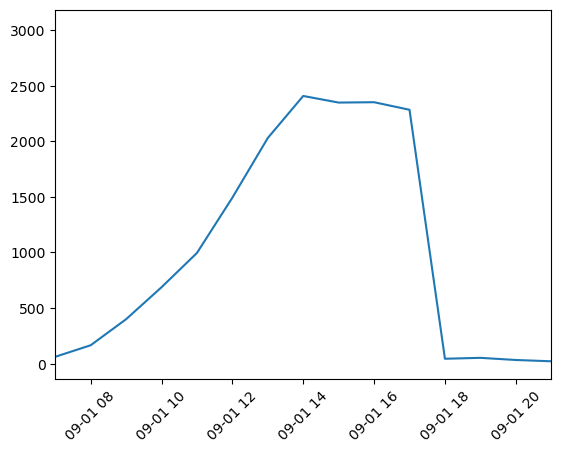

In [9]:
blh = filtered_ds['blh'].values.squeeze()
plt.plot(filtered_ds['valid_time'],blh)
plt.xticks(rotation=45)
plt.xlim(filtered_ds['valid_time'][10],filtered_ds['valid_time'][24])

In [10]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")

# Example: print or pass them into other analysis
# print(core_processed_files)


In [11]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_sum = {extract_flight_number(f) for f in flight_sum_files}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in flight_sum_files if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [12]:
ds_height = xr.open_dataset(filtered_nc[11])
ds_height

<xarray.Dataset> Size: 178MB
Dimensions:         (data_point: 18090, sps32: 32, sps04: 4, sps01: 1,
                     sps02: 2, sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/137)
    Time            (data_point) datetime64[ns] 145kB ...
    IAS_RVSM        (data_point, sps32) float32 2MB ...
    IAS_RVSM_FLAG   (data_point, sps32) float32 2MB ...
    TAS_RVSM        (data_point, sps32) float32 2MB ...
    TAS_RVSM_FLAG   (data_point, sps32) float32 2MB ...
    TAT_DI_R        (data_point, sps32) float32 2MB ...
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 72kB ...
    TDEW_C_U_FLAG   (data_point, sps01) float32 72kB ...
    U_NOTURB        (data_point, sps01) float32 72kB ...
    U_NOTURB_FLAG   (data_point, sps01) float32 72kB ...
    V_NOTURB        (data_point, sps01) float32 72kB ...
    V_NOTURB_FLAG   (data_point, sps01) float32 72kB ...
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b748 on 02-OCT-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        10:51:07-15:52:36
    History:             Dataset /home/tardis/data/ncdata/core_faam_20121002_...

In [13]:
ds_height_ressampled = ds_height.resample(Time="1h").mean()
ds_height_ressampled

<xarray.Dataset> Size: 59kB
Dimensions:         (data_point: 6, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                     sps64: 64)
Coordinates:
  * data_point      (data_point) datetime64[ns] 48B 2012-10-02T10:00:00 ... 2...
Dimensions without coordinates: sps32, sps04, sps01, sps02, sps64
Data variables: (12/136)
    IAS_RVSM        (data_point, sps32) float32 768B 4.169 4.17 ... 94.74 94.74
    IAS_RVSM_FLAG   (data_point, sps32) float32 768B 0.005629 0.005629 ... 0.0
    TAS_RVSM        (data_point, sps32) float32 768B 4.35 4.351 ... 126.5 126.5
    TAS_RVSM_FLAG   (data_point, sps32) float32 768B 1.006 1.006 ... 0.1026
    TAT_DI_R        (data_point, sps32) float32 768B 303.9 303.9 ... 275.5 275.5
    TAT_DI_R_FLAG   (data_point, sps32) float32 768B 1.18 1.18 ... 0.1023 0.1026
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 24B nan nan ... 0.5891 2.53
    TDEW_C_U_FLAG   (data_point, sps01) float32 24B 3.0 3.0 ... 0.0825 0.2281
    U_NOTURB        (data_point, sps01) float32 24B -0.004043 ... -2.099
    U_NOTURB_FLAG   (data_point, sps01) float32 24B 3.0 2.719 ... 0.69 0.8334
    V_NOTURB        (data_point, sps01) float32 24B -0.6619 -0.8347 ... 0.1677
    V_NOTURB_FLAG   (data_point, sps01) float32 24B 3.0 2.719 ... 0.69 0.8334
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b748 on 02-OCT-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        10:51:07-15:52:36
    History:             Dataset /home/tardis/data/ncdata/core_faam_20121002_...

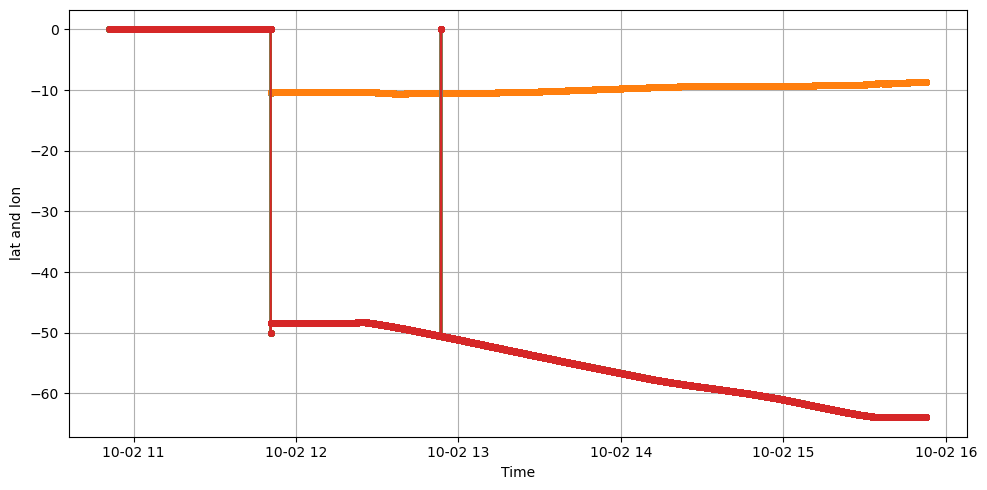

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(ds_height['Time'], ds_height['LAT_GIN'], label='lat',marker='o', linestyle='-', markersize=4)
plt.plot(ds_height['Time'], ds_height['LON_GIN'], label='lat',marker='o', linestyle='-', markersize=4)
plt.ylabel("lat and lon")
plt.xlabel("Time")
#plt.legend()
#plt.title("Flight Altitude vs Boundary Layer Height")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
flight_lat = ds_height_ressampled['LAT_GPS']
flight_lon = ds_height_ressampled['LON_GPS']
flight_hgt = ds_height_ressampled['GPS_ALT']

reanalisys_data_lat = ds2['latitude']
reanalisys_data_lon = ds2['longitude']
boundary_layer_height = ds2['blh']

In [15]:

def round_to_grid(value, resolution=0.25):
    return np.round(value / resolution) * resolution

# Step 1: Round aircraft lat/lon to match 0.25° grid
flight_lat_rounded = round_to_grid(flight_lat)
flight_lon_rounded = round_to_grid(flight_lon)

# Step 2: Convert reanalysis lat/lon to numpy arrays for fast lookup
rean_lat = ds['latitude'].values
rean_lon = ds['longitude'].values

# Step 3: Match each rounded lat/lon to the nearest index in the reanalysis grid
def get_index(arr, val):
    return np.abs(arr - val).argmin()

# Step 4: Extract BLH values along the flight path
blh_values = []
for t in range(len(ds_height_ressampled['data_point'])):
    lat_val = flight_lat_rounded.isel(data_point=t).item()
    lon_val = flight_lon_rounded.isel(data_point=t).item()

    lat_idx = get_index(rean_lat, lat_val)
    lon_idx = get_index(rean_lon, lon_val)

    blh = boundary_layer_height.isel(valid_time=t, latitude=lat_idx, longitude=lon_idx).item()
    blh_values.append(blh)



In [19]:
blh_values

[211.26123046875,
 36.702083587646484,
 58.62178039550781,
 89.27549743652344,
 209.1505126953125,
 39.11711120605469]

In [17]:
# Step 5: Create a pandas DataFrame for plotting
plot_df = pd.DataFrame({
    'time': ds_height_ressampled['data_point'].values,
    'flight_height': flight_hgt.values.squeeze(),
    'boundary_layer_height': blh_values
})

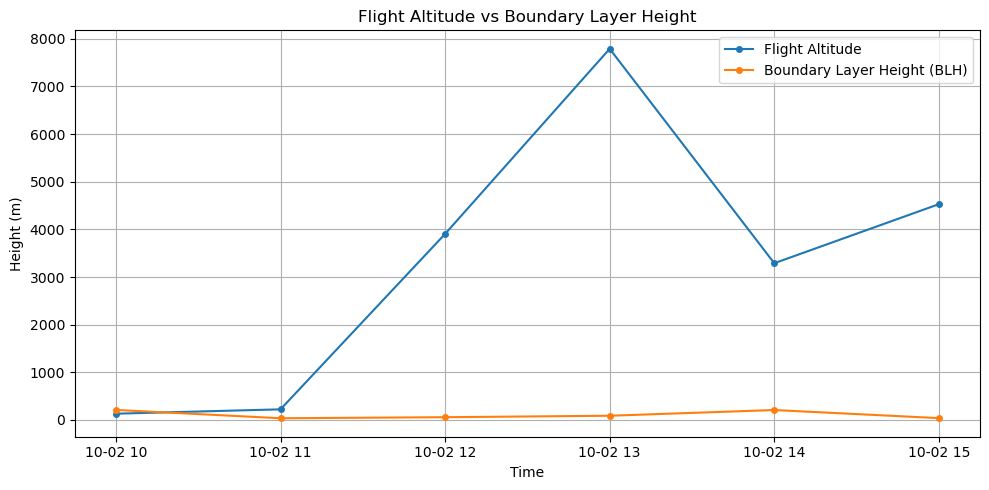

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(plot_df['time'], plot_df['flight_height'], label='Flight Altitude',marker='o', linestyle='-', markersize=4)
plt.plot(plot_df['time'], plot_df['boundary_layer_height'], label='Boundary Layer Height (BLH)',marker='o', linestyle='-', markersize=4)
plt.ylabel("Height (m)")
plt.xlabel("Time")
plt.legend()
plt.title("Flight Altitude vs Boundary Layer Height")
plt.grid(True)
plt.tight_layout()
plt.show()

(18090,)
(18090, 1)
(18090, 1)
(18090, 1)


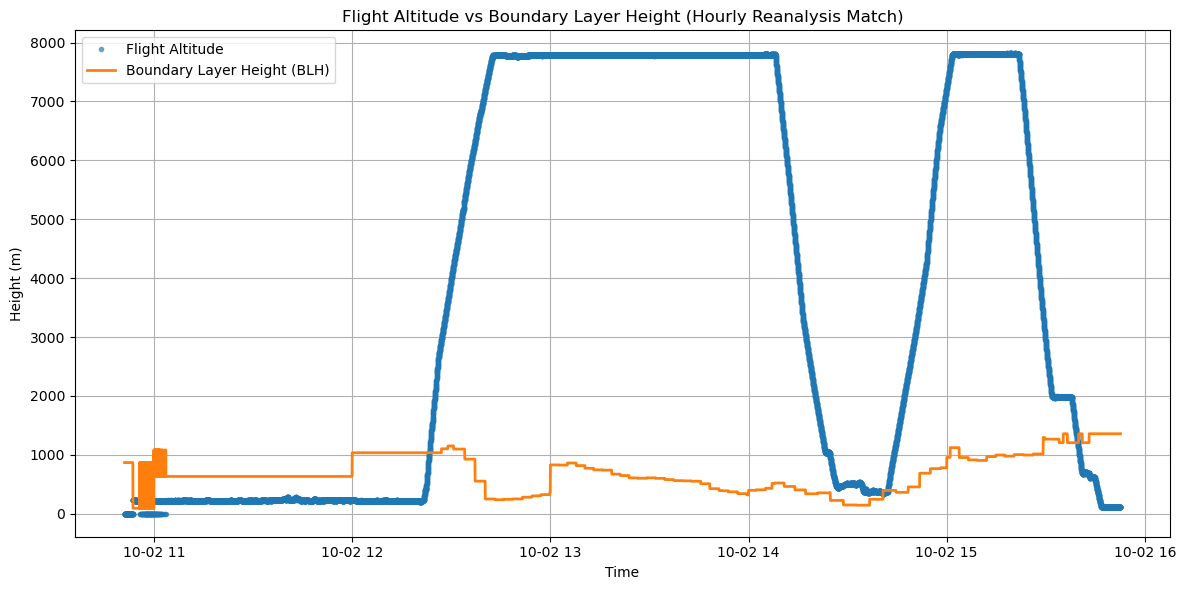

In [31]:
# Helper to round coordinates to the reanalysis grid resolution
def round_to_grid(value, resolution=0.25):
    return np.round(value / resolution) * resolution

# 1. Prepare aircraft data
flight_time = ds_height['Time']
flight_lat = round_to_grid(ds_height['LAT_GPS'])
flight_lon = round_to_grid(ds_height['LON_GPS'])
flight_hgt = ds_height['GPS_ALT']

# 2. Round aircraft time to the hour (assumes datetime64[ns])
flight_time_rounded = pd.to_datetime(flight_time.values).floor('h')

# 3. Reanalysis lat/lon grid
rean_lat = ds['latitude'].values
rean_lon = ds['longitude'].values
rean_time = pd.to_datetime(ds['valid_time'].values)


print(np.shape(flight_time_rounded))
print(np.shape(flight_lat.values))
print(np.shape(flight_lon.values))
print(np.shape(flight_hgt.values))

# 4. Create DataFrame from aircraft
df_aircraft = pd.DataFrame({
    'time': pd.to_datetime(flight_time.values),
    'time_hour': flight_time_rounded,
    'lat': flight_lat.values.squeeze(),
    'lon': flight_lon.values.squeeze(),
    'height': flight_hgt.values.squeeze()
})

# 5. Lookup function for each row
def get_blh(row):
    try:
        # Match nearest lat/lon in reanalysis grid
        lat_idx = np.abs(rean_lat - row['lat']).argmin()
        lon_idx = np.abs(rean_lon - row['lon']).argmin()

        # Find matching time index in reanalysis data
        time_idx = np.where(rean_time == row['time_hour'])[0]
        if len(time_idx) == 0:
            return np.nan  # if time not found
        time_idx = time_idx[0]

        # Extract BLH
        return ds['blh'].isel(valid_time=time_idx, latitude=lat_idx, longitude=lon_idx).item()
    except:
        return np.nan

# 6. Apply the lookup
df_aircraft['blh'] = df_aircraft.apply(get_blh, axis=1)

# 7. Plot
plt.figure(figsize=(12, 6))
plt.plot(df_aircraft['time'], df_aircraft['height'], '.', label='Flight Altitude', alpha=0.6)
plt.plot(df_aircraft['time'], df_aircraft['blh'], '-', label='Boundary Layer Height (BLH)', linewidth=2)
plt.ylabel("Height (m)")
plt.xlabel("Time")
plt.legend()
plt.title("Flight Altitude vs Boundary Layer Height (Hourly Reanalysis Match)")
plt.grid(True)
plt.tight_layout()
plt.show()

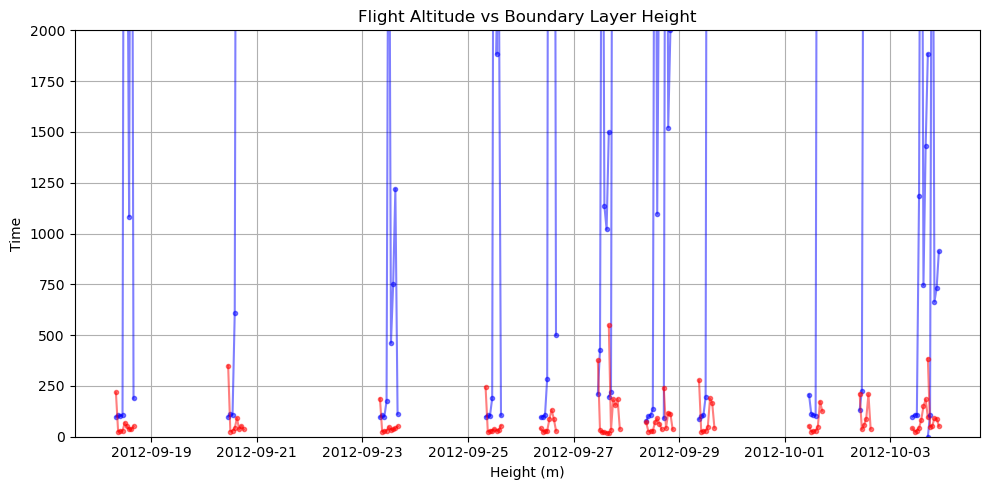

In [100]:

plt.figure(figsize=(10, 5))

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph):

    ds_height = xr.open_dataset(nc_file)
    ds_height_ressampled = ds_height.resample(Time="1h").mean()

    flight_lat = ds_height_ressampled['LAT_GPS']
    flight_lon = ds_height_ressampled['LON_GPS']
    flight_hgt = ds_height_ressampled['GPS_ALT']
    
    reanalisys_data_lat = ds2['latitude']
    reanalisys_data_lon = ds2['longitude']
    boundary_layer_height = ds2['blh']


    # Step 1: Round aircraft lat/lon to match 0.25° grid
    flight_lat_rounded = round_to_grid(flight_lat)
    flight_lon_rounded = round_to_grid(flight_lon)
    
    # Step 2: Convert reanalysis lat/lon to numpy arrays for fast lookup
    rean_lat = ds2['latitude'].values
    rean_lon = ds2['longitude'].values

    # Step 4: Extract BLH values along the flight path
    blh_values = []
    for t in range(len(ds_height_ressampled['data_point'])):
        lat_val = flight_lat_rounded.isel(data_point=t).item()
        lon_val = flight_lon_rounded.isel(data_point=t).item()
    
        lat_idx = get_index(rean_lat, lat_val)
        lon_idx = get_index(rean_lon, lon_val)
    
        blh = boundary_layer_height.isel(valid_time=t, latitude=lat_idx, longitude=lon_idx).item()
        blh_values.append(blh)

    # Step 5: Create a pandas DataFrame for plotting
    plot_df = pd.DataFrame({
        'time': ds_height_ressampled['data_point'].values,
        'flight_height': flight_hgt.values.squeeze(),
        'boundary_layer_height': blh_values
    })

    # Plot
    plt.plot(
        plot_df['time'],
        plot_df['flight_height'],
        marker=".",
        linestyle='-',
        alpha=0.5,
        color='blue',
        label=nc_file.split("/")[-1]  # Optional: show filename as label
    )
    plt.plot(
        plot_df['time'],
        plot_df['boundary_layer_height'],
        marker=".",
        linestyle='-',
        alpha=0.5,
        color='red',
        label='Boundary Layer Height (BLH)'  # Optional: show filename as label
    )

# Formatting
plt.xlabel("Height (m)")
plt.ylabel("Time")
plt.ylim(0,2000)
#plt.xlim(0,400)
plt.grid()
#plt.legend(loc="best", fontsize=8)
plt.title("Flight Altitude vs Boundary Layer Height")
plt.tight_layout()
plt.show()

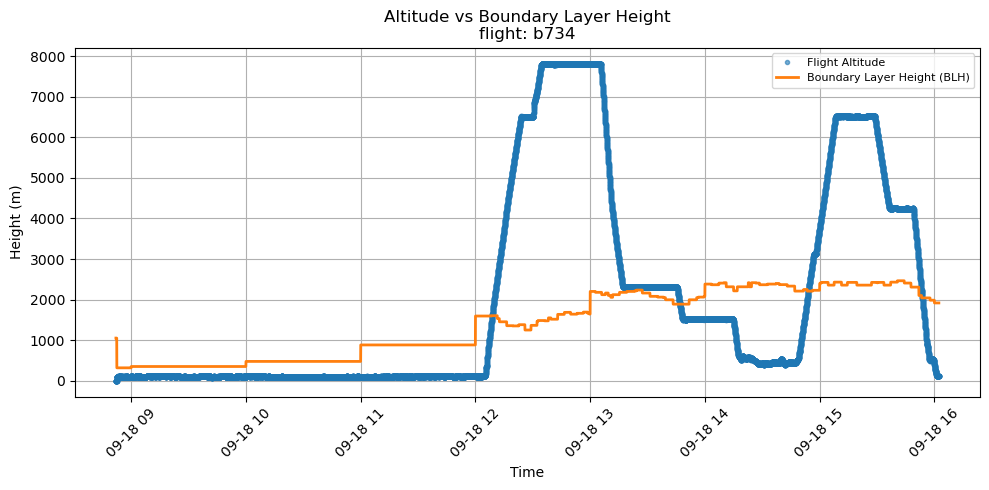

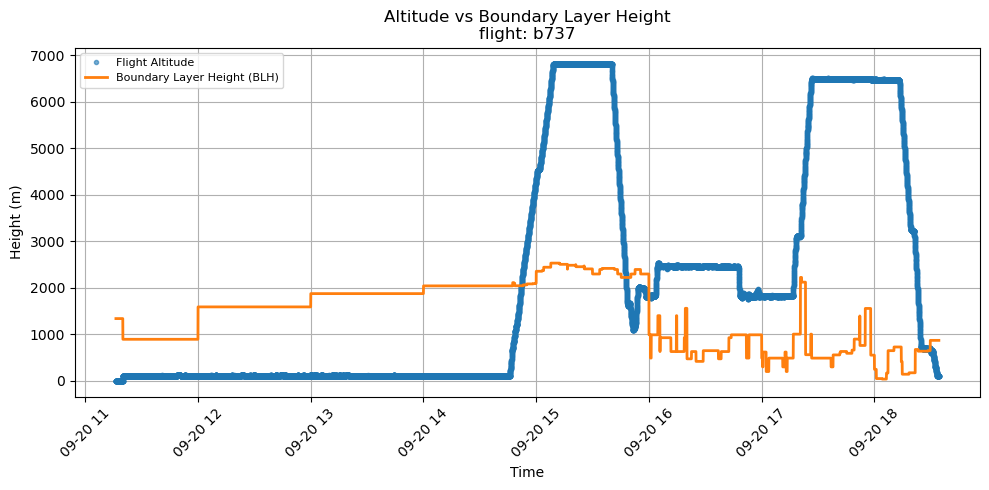

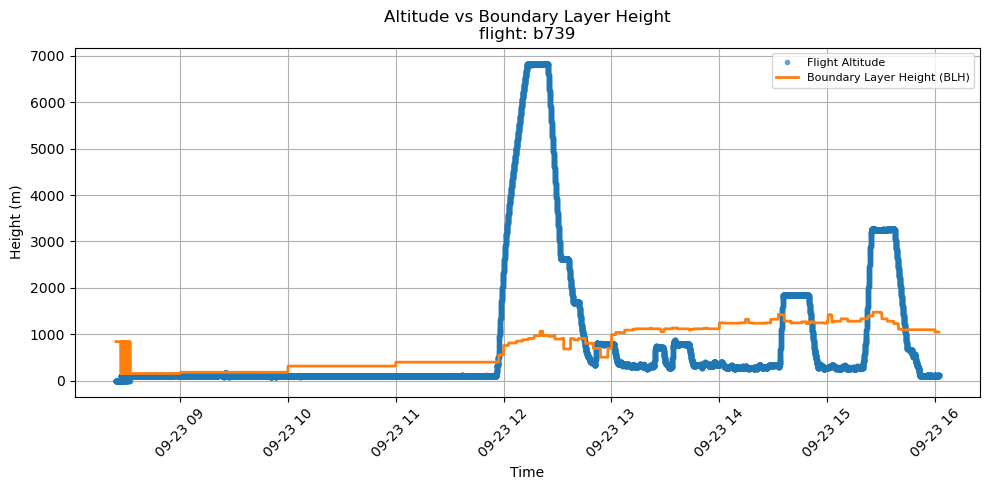

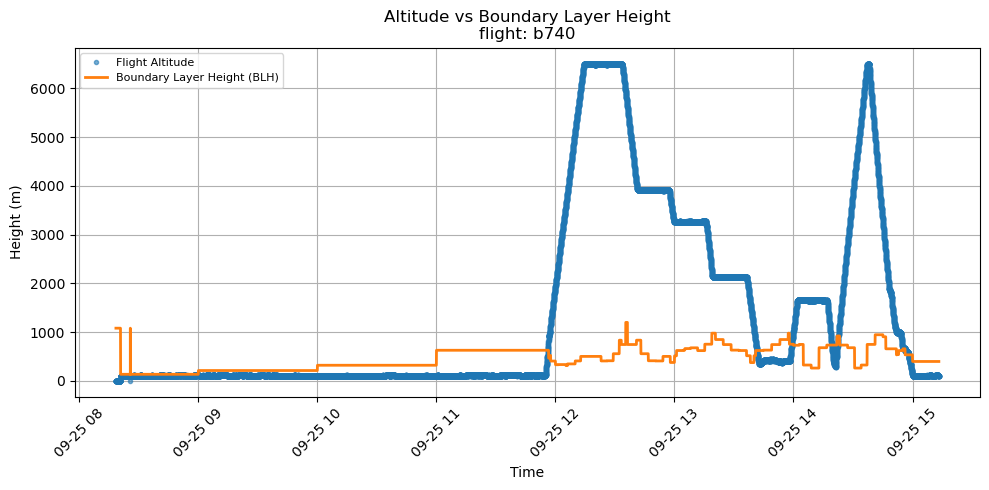

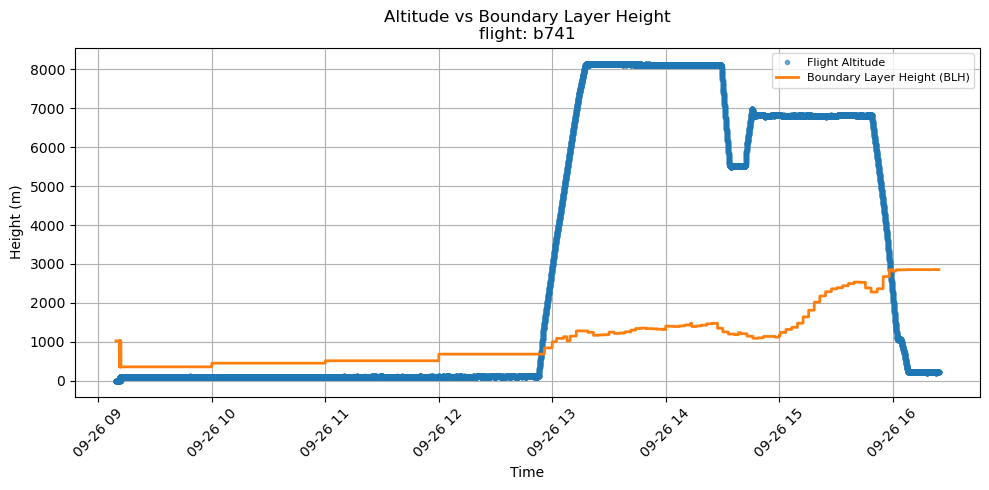

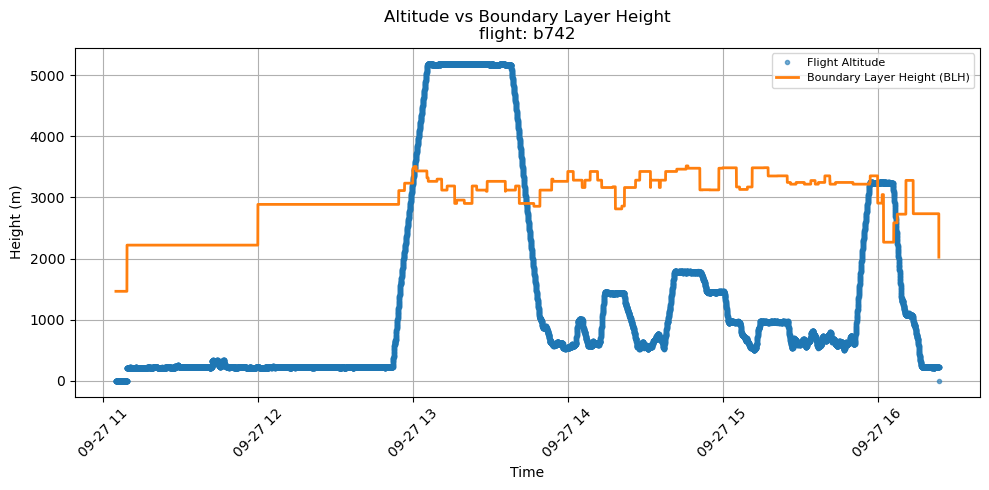

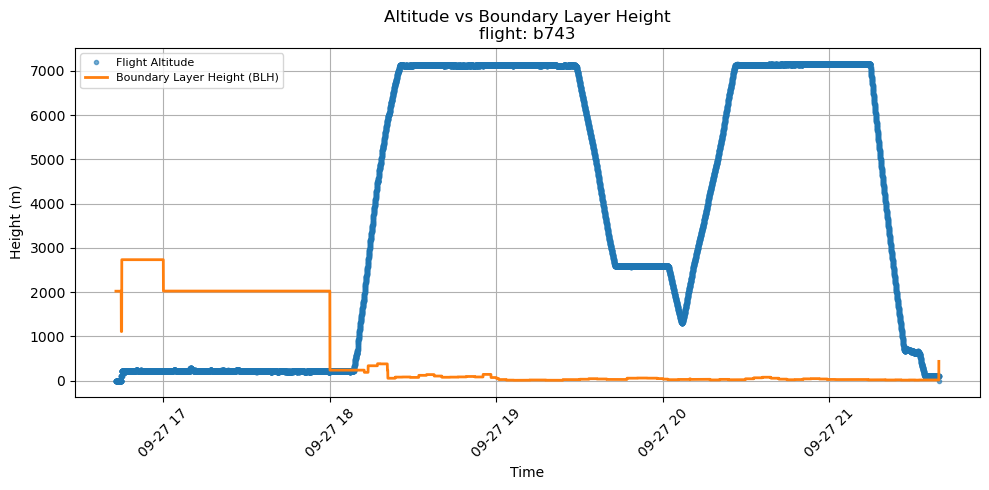

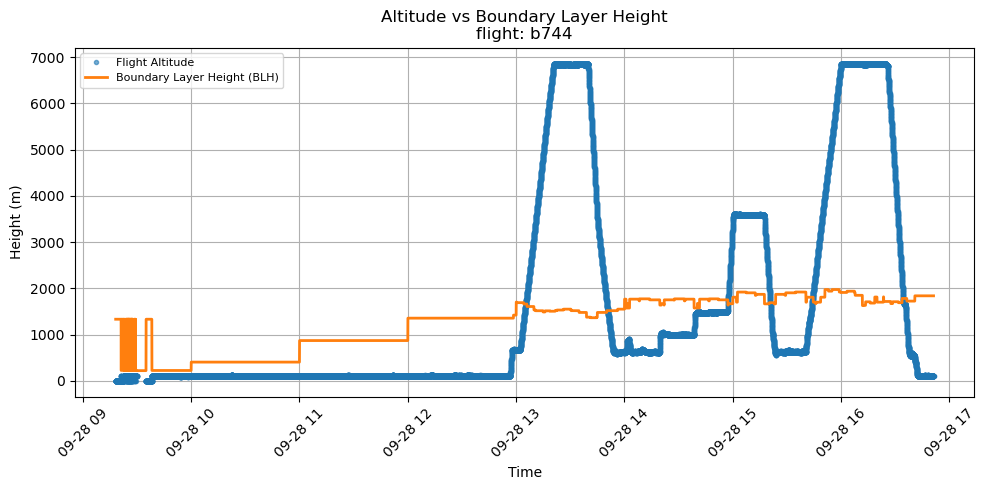

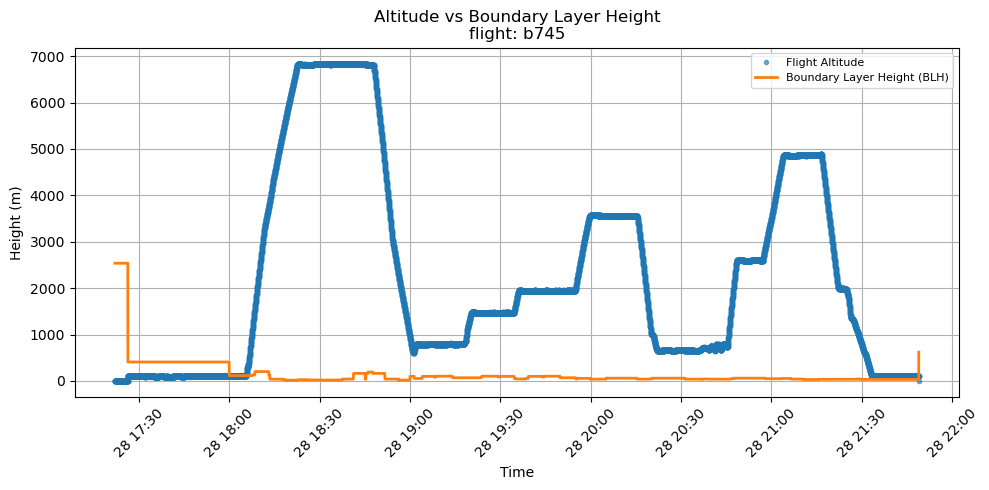

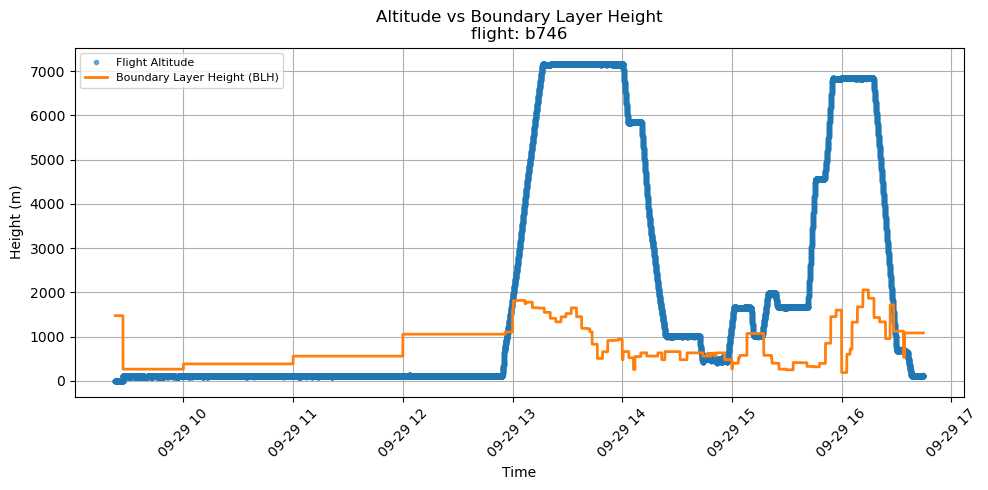

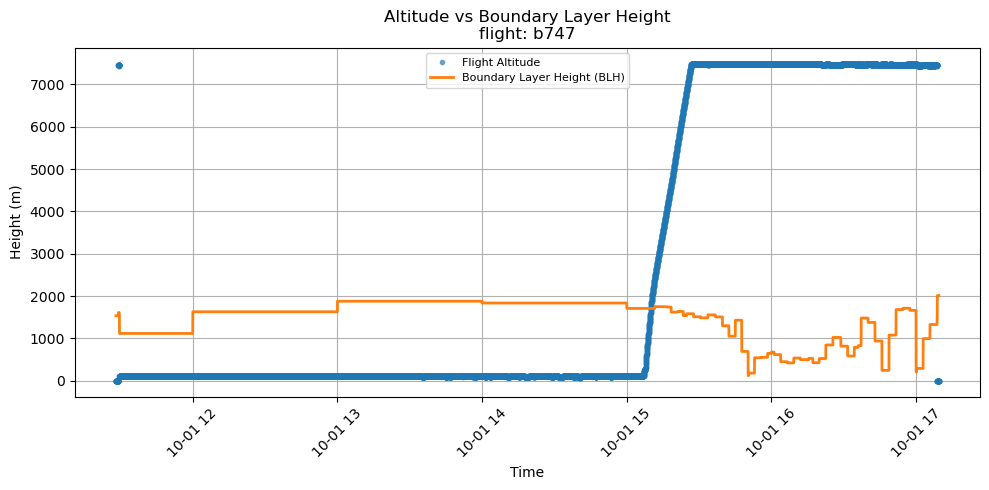

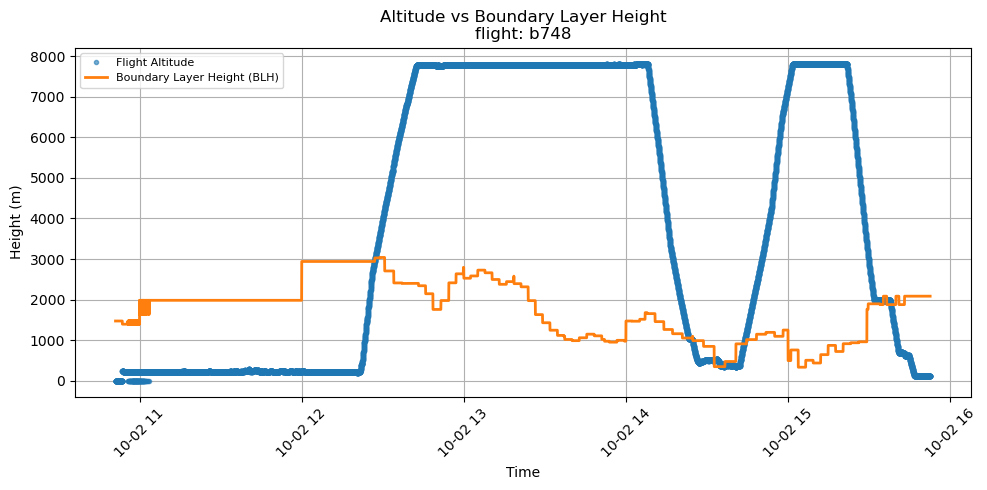

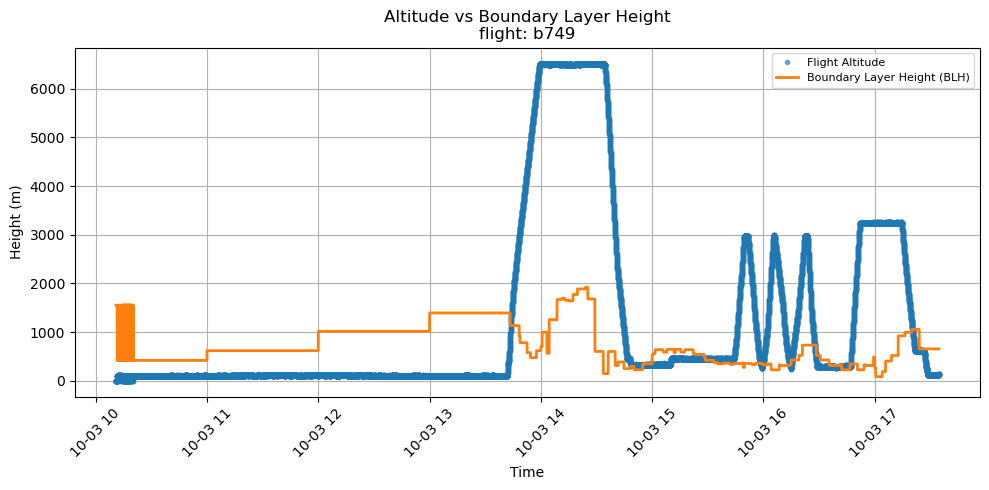

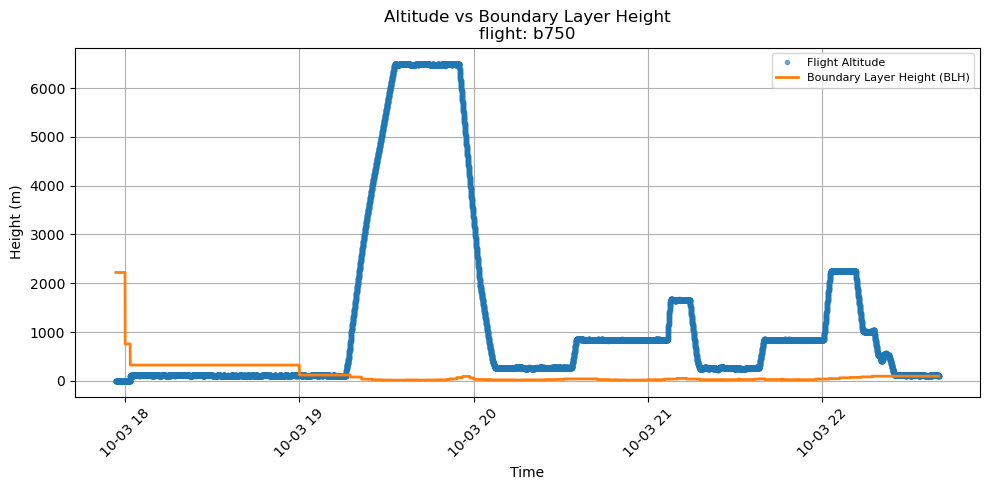

In [41]:
# Iterate over all matching flights
for nc_file in filtered_nc:

    ds_height = xr.open_dataset(nc_file)

    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"

    # 1. Prepare aircraft data
    flight_time = ds_height['Time']
    flight_lat = round_to_grid(ds_height['LAT_GPS'])
    flight_lon = round_to_grid(ds_height['LON_GPS'])
    flight_hgt = ds_height['GPS_ALT']
    
    # 2. Round aircraft time to the hour (assumes datetime64[ns])
    flight_time_rounded = pd.to_datetime(flight_time.values).floor('h')
    
    # 3. Reanalysis lat/lon grid
    rean_lat = ds2['latitude'].values
    rean_lon = ds2['longitude'].values
    rean_time = pd.to_datetime(ds2['valid_time'].values)
    
    # 4. Create DataFrame from aircraft
    df_aircraft = pd.DataFrame({
        'time': pd.to_datetime(flight_time.values),
        'time_hour': flight_time_rounded,
        'lat': flight_lat.values.squeeze(),
        'lon': flight_lon.values.squeeze(),
        'height': flight_hgt.values.squeeze()
    })

    # 6. Apply the lookup
    df_aircraft['blh'] = df_aircraft.apply(get_blh, axis=1)

    plt.figure(figsize=(10, 5))
    #Plot for every flight
    plt.plot(df_aircraft['time'], df_aircraft['height'], '.', label='Flight Altitude', alpha=0.6)
    plt.plot(df_aircraft['time'], df_aircraft['blh'], '-', label='Boundary Layer Height (BLH)', linewidth=2)
    # Formatting
    plt.ylabel("Height (m)")
    plt.xlabel("Time")
    #plt.ylim(0,2000)
    #plt.xlim(0,400)
    plt.tick_params(axis='x', rotation=45)
    plt.grid()
    plt.legend(loc="best", fontsize=8)
    plt.title(f"Altitude vs Boundary Layer Height\nflight: {flight_number}")
    plt.tight_layout()
    plt.savefig(f'./Height/Height_and_BDL_v1_{flight_number}.png', dpi=300)

# Formatting
#plt.ylabel("Height (m)")
#plt.xlabel("Time")
#plt.ylim(0,2000)
#plt.xlim(0,400)
#plt.grid()
#plt.legend(loc="best", fontsize=8)
#plt.title("Flight Altitude vs Boundary Layer Height")
#plt.tight_layout()
#plt.show()